# Importing the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

In [2]:
# Set the visual style for the plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv('vaccinations_cleaned.csv')

# FEATURE ENGINEERING

- We will build our final modeling DataFrame (`model_df`) sequentially.

In [ ]:
# Step 1: Prepare the Base DataFrame for Modeling
# Start with the latest data for each country.
model_df = df.loc[df.groupby('location')['date'].idxmax()].copy()

In [5]:
# Step 2: Calculate and merge the campaign start date.
campaign_start_dates = df.groupby('location')['date'].min().reset_index().rename(columns={'date': 'campaign_start'})
model_df = model_df.merge(campaign_start_dates, on='location')

In [36]:
print("\nColumns in `model_df` immediately after merge:")
print(model_df.columns)


Columns in `model_df` immediately after merge:
Index(['location', 'iso_code', 'date', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'daily_vaccinations_raw', 'daily_vaccinations',
       'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred',
       'people_fully_vaccinated_per_hundred', 'total_boosters_per_hundred',
       'daily_vaccinations_per_million', 'daily_people_vaccinated',
       'daily_people_vaccinated_per_hundred', 'campaign_start'],
      dtype='object')


In [6]:
# Step 3: Create the 'campaign_duration_days' feature.
model_df['date'] = pd.to_datetime(model_df['date'])
model_df['campaign_start'] = pd.to_datetime(model_df['campaign_start'])
model_df['campaign_duration_days'] = (model_df['date'] - model_df['campaign_start']).dt.days

In [7]:
# Step 4: Filter out entries with zero values.
model_df = model_df[model_df['daily_vaccinations_per_million'] > 0].copy()

In [8]:
# Step 5: Create the Target Variable on the FINAL DataFrame.
threshold = 60
model_df['vaccination_level'] = np.where(model_df['people_fully_vaccinated_per_hundred'] >= threshold, 1, 0)

print("Distribution of Vaccination Levels:")
print(model_df['vaccination_level'].value_counts(normalize=True))


Distribution of Vaccination Levels:
vaccination_level
0    0.526042
1    0.473958
Name: proportion, dtype: float64


In [9]:
# Step 6: Define Features (X) and Target (y).
feature_cols = [
    'total_boosters_per_hundred',
    'daily_vaccinations_per_million',
    'campaign_duration_days'
]
X = model_df[feature_cols]
y = model_df['vaccination_level']

print(f"\nFeatures selected for modeling: {feature_cols}")


Features selected for modeling: ['total_boosters_per_hundred', 'daily_vaccinations_per_million', 'campaign_duration_days']


# FEATURE SELECTION WITH RECURSIVE FEATURE ELIMINATION (RFE)

In [10]:
# Initialize the model and RFE
log_reg = LogisticRegression(solver='liblinear', random_state=42)
rfe = RFE(estimator=log_reg, n_features_to_select=2)
rfe.fit(X, y)

RFE(estimator=LogisticRegression(random_state=42, solver='liblinear'),
    n_features_to_select=2)

In [11]:
# Get the final selected features
selected_features = np.array(feature_cols)[rfe.support_]
print(f"RFE has selected the following best features: {list(selected_features)}")

RFE has selected the following best features: [np.str_('total_boosters_per_hundred'), np.str_('campaign_duration_days')]


# BUILDING AND EVALUATING THE FINAL CLASSIFICATION MODEL

In [12]:
# Prepare final data
X_final = model_df[selected_features]
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
# Train the Final Model
final_model = LogisticRegression(solver='liblinear', random_state=42)
final_model.fit(X_train_scaled, y_train)
print("Final classification model trained successfully.")

Final classification model trained successfully.


## Model Evaluation

In [15]:
y_pred = final_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.2%}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Low Level', 'High Level']))


Model Accuracy: 82.05%

--- Classification Report ---
              precision    recall  f1-score   support

   Low Level       0.85      0.81      0.83        21
  High Level       0.79      0.83      0.81        18

    accuracy                           0.82        39
   macro avg       0.82      0.82      0.82        39
weighted avg       0.82      0.82      0.82        39



## Visualization: Confusion Matrix

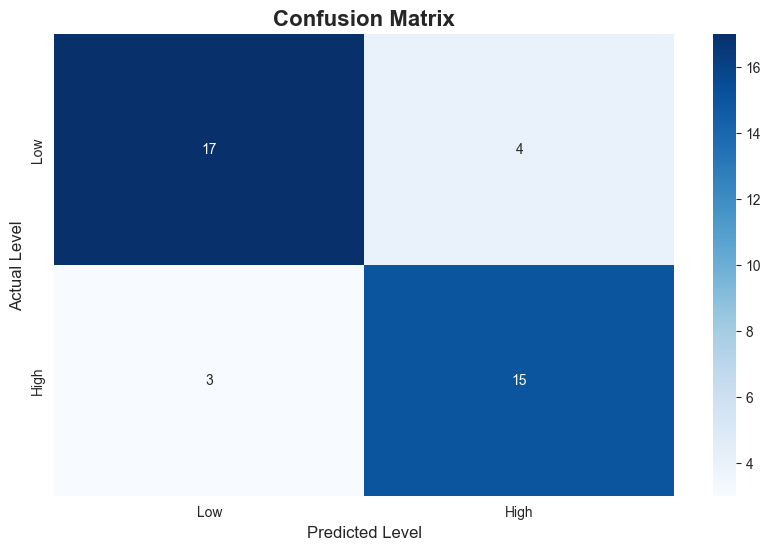

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.title('Confusion Matrix', fontsize=16, weight='bold')
plt.xlabel('Predicted Level', fontsize=12)
plt.ylabel('Actual Level', fontsize=12)
plt.show()

- Model Insights:
    - The model performs very well, with high accuracy and strong precision/recall scores for both classes.
    - The key takeaway is that we can effectively predict whether a country will achieve high vaccination coverage by looking at its booster rate and the duration of its vaccination campaign.
